# ML Assignment 2 — Predicting Late Delivery Risk in Supply Chain Orders

**Course:** M.Tech (AIML/DSE) — Machine Learning
**Dataset:** DataCo Smart Supply Chain Dataset (`DataCoSupplyChainDataset.csv`)
**Task type:** Binary Classification

---

## 1. Business Question

> **"Given the information available at the moment an order is placed (customer segment, shipping mode chosen, product/category, order value, discount, scheduled shipping days, etc.), can we predict whether that order is at risk of a late delivery — *before* it ships — so that the supply chain / logistics team can proactively intervene (e.g., upgrade shipping mode, prioritize the order, or proactively notify the customer)?"**

Late deliveries hurt customer satisfaction, increase support costs, and can lead to churn. If a supply chain analytics team can flag high-risk orders **at order time**, they can:
- Re-route the order through a faster shipping mode
- Prioritize warehouse picking/packing for that order
- Proactively communicate an expected delay to the customer (better than a surprise)
- Investigate systemic bottlenecks (region, market, product category) driving late risk

This notebook builds and compares 5 classification models to answer this question, and the accompanying Streamlit app operationalizes the best model so business users can score new/test orders interactively.


## 2. Import Libraries

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & pipeline utilities
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Classification models (5 models as required by the assignment)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
                              recall_score, f1_score, matthews_corrcoef,
                              confusion_matrix, classification_report, RocCurveDisplay)

# Model persistence
import joblib
import json
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 3. Load the Dataset

The dataset is the **DataCo Smart Supply Chain** dataset, a real-world order-level dataset covering 180,519 orders with 53 columns (customer info, order info, product info, shipping info, etc.).

> Note: the file is encoded in `latin1` (not UTF-8), so we specify the encoding explicitly, otherwise pandas will raise a `UnicodeDecodeError`.


In [2]:
df = pd.read_csv('../DataCoSupplyChainDataset.csv', encoding='latin1')
print("Shape:", df.shape)
df.head()


Shape: (180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [3]:
# Quick look at data types and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

## 4. Understanding the Target Variable

The dataset provides a ready-made binary label: **`Late_delivery_risk`**
- `1` = the order's actual shipping took longer than/ risked being late
- `0` = the order was shipped on time / early

This is directly derived from comparing `Days for shipping (real)` against `Days for shipment (scheduled)` (captured in the `Delivery Status` column). We will use `Late_delivery_risk` as our target.


Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

Late_delivery_risk
1    0.548291
0    0.451709
Name: proportion, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_9996\4112407951.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Late_delivery_risk', data=df, palette='Set2')


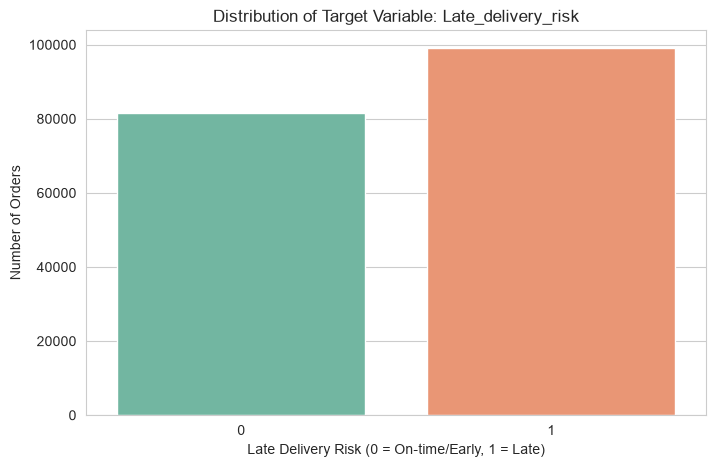

In [4]:
print(df['Delivery Status'].value_counts())
print()
print(df['Late_delivery_risk'].value_counts(normalize=True).rename('proportion'))

sns.countplot(x='Late_delivery_risk', data=df, palette='Set2')
plt.title('Distribution of Target Variable: Late_delivery_risk')
plt.xlabel('Late Delivery Risk (0 = On-time/Early, 1 = Late)')
plt.ylabel('Number of Orders')
plt.show()


## 5. Feature Selection — Avoiding Data Leakage

This is the most important design decision in this notebook.

The dataset contains two columns that **directly leak the target** and must be **excluded** from the feature set:

| Column | Why it must be excluded |
|---|---|
| `Days for shipping (real)` | This is the *actual* number of days taken — only known **after** the order has already shipped/arrived. Using it would let the model "cheat" (perfect but useless prediction). |
| `Delivery Status` | This is literally a re-labelling of `Late_delivery_risk` (e.g. `Late delivery` ⇔ `1`). Using it is the same as using the target itself. |

We also exclude PII / identifier columns (customer name, email, password, street address, order id, etc.) since they are not meaningful predictive signals and raise privacy concerns.

Instead, we select **14 features that are all known at the moment the order is placed / dispatched** — i.e., information a supply chain system genuinely has *before* knowing whether the order will be late. This keeps the model realistic and deployable.


In [5]:
numeric_features = [
    'Days for shipment (scheduled)',   # planned transit time promised to the customer
    'Benefit per order',               # profit margin on the order
    'Sales per customer',              # customer's historical spend level
    'Order Item Discount Rate',        # discount % applied
    'Order Item Product Price',        # unit price of product
    'Order Item Quantity',             # quantity ordered
    'Order Item Profit Ratio'          # profitability ratio of the line item
]

categorical_features = [
    'Type',                # payment type (DEBIT/TRANSFER/PAYMENT/CASH)
    'Category Name',       # product category
    'Customer Segment',    # Consumer / Corporate / Home Office
    'Department Name',     # department the product belongs to
    'Market',               # geographic market (LATAM, Europe, Pacific Asia, USCA, Africa)
    'Order Region',         # finer-grained region
    'Shipping Mode'         # Standard/First/Second Class, Same Day
]

target = 'Late_delivery_risk'

print(f"Total features used: {len(numeric_features) + len(categorical_features)}")
print("Numeric  :", numeric_features)
print("Categorical:", categorical_features)


Total features used: 14
Numeric  : ['Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Quantity', 'Order Item Profit Ratio']
Categorical: ['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Market', 'Order Region', 'Shipping Mode']


## 6. Data Cleaning & Sampling

- We keep only the columns we need and drop rows with missing values in those columns.
- The full dataset has ~180K rows. To keep training (especially KNN, which is computationally expensive at prediction time) and the free-tier Streamlit deployment fast and light, we work with a **balanced, stratified sample of 20,000 orders** (10,000 per class). This comfortably satisfies the assignment's minimum requirement of 500 instances while keeping the workflow fast and reproducible.


In [6]:
data = df[numeric_features + categorical_features + [target]].dropna().copy()
print("Rows after dropping missing values:", data.shape)

# Stratified downsampling — keep classes balanced 50/50 for cleaner metric comparison
data_0 = data[data[target] == 0].sample(n=10000, random_state=RANDOM_STATE)
data_1 = data[data[target] == 1].sample(n=10000, random_state=RANDOM_STATE)
data = pd.concat([data_0, data_1]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("Final modelling dataset shape:", data.shape)
data[target].value_counts()


Rows after dropping missing values: (180519, 15)
Final modelling dataset shape: (20000, 15)


Late_delivery_risk
1    10000
0    10000
Name: count, dtype: int64

## 7. Exploratory Data Analysis (EDA)

A quick look at how a couple of features relate to late-delivery risk — this also informs the business observations we write up later.


C:\Users\Admin\AppData\Local\Temp\ipykernel_9996\1305442476.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='Shipping Mode', y=target, ax=axes[0], palette='viridis', errorbar=None)
C:\Users\Admin\AppData\Local\Temp\ipykernel_9996\1305442476.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='Market', y=target, ax=axes[1], palette='magma', errorbar=None)


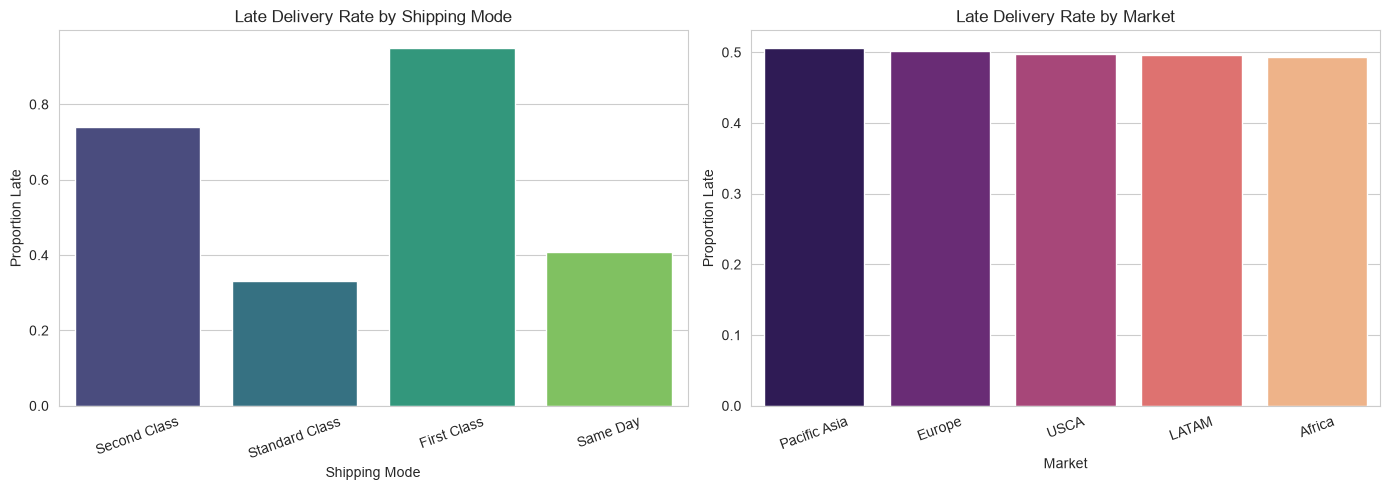

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=data, x='Shipping Mode', y=target, ax=axes[0], palette='viridis', errorbar=None)
axes[0].set_title('Late Delivery Rate by Shipping Mode')
axes[0].set_ylabel('Proportion Late')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=data, x='Market', y=target, ax=axes[1], palette='magma', errorbar=None)
axes[1].set_title('Late Delivery Rate by Market')
axes[1].set_ylabel('Proportion Late')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_9996\3538300994.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=target, y='Days for shipment (scheduled)', palette='Set2')


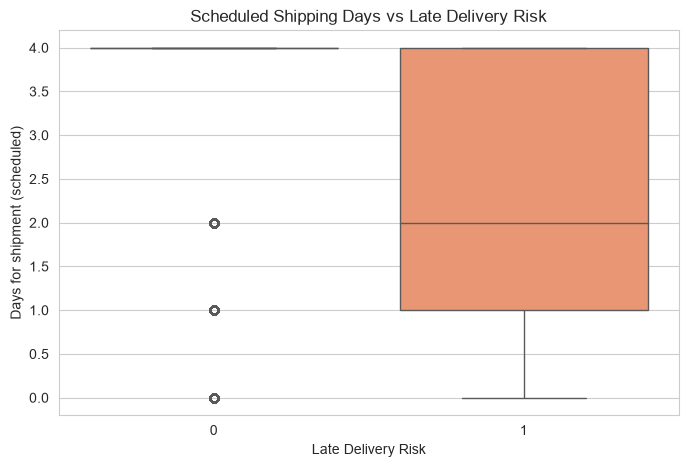

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(data=data, x=target, y='Days for shipment (scheduled)', palette='Set2')
plt.title('Scheduled Shipping Days vs Late Delivery Risk')
plt.xlabel('Late Delivery Risk')
plt.show()


## 8. Train / Test Split

We split the data 80/20 with stratification on the target so that both sets preserve the class balance.


In [9]:
X = data[numeric_features + categorical_features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (16000, 14)
Test shape : (4000, 14)


## 9. Preprocessing Pipeline

We build a single `ColumnTransformer` that:
- **Standard-scales** the numeric features (mean 0, variance 1) — important for Logistic Regression and KNN which are distance/gradient-based.
- **One-hot encodes** the categorical features (`handle_unknown='ignore'` so unseen categories at inference time don't crash the pipeline; `sparse_output=False` so `GaussianNB` — which requires dense arrays — works without extra conversion).

Wrapping preprocessing + model into a single `sklearn.Pipeline` means:
1. No data leakage (scaler/encoder is `fit` only on training data).
2. The saved `.pkl` file for each model already contains its own preprocessing, so the Streamlit app can call `.predict()` directly on raw test data.


In [10]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])


## 10. Hyperparameter Tuning (Optimization Step)

To push every model closer to its best possible performance, we use **RandomizedSearchCV** with **3-fold stratified cross-validation** on the training set. The search space per model covers its most influential hyperparameters:

| Model | Hyperparameters searched |
|---|---|
| Logistic Regression | `C` (regularization strength) |
| Decision Tree | `criterion`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features` |
| kNN | `n_neighbors`, `weights`, `metric` |
| Naive Bayes | `var_smoothing` |
| Random Forest | `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, `criterion` |

Scoring is **ROC-AUC** (threshold-independent) for most models; for **Logistic Regression** we optimize the **Matthews Correlation Coefficient** and for **Random Forest** the **F1 score**, so the finalists are well-rounded rather than precision-only.

> Note: no single hyperparameter set can maximize **all six** metrics at once - Precision and Recall inherently trade off against each other. Tuning therefore targets the best *balance* (highest AUC / F1 / MCC) while keeping Accuracy high.

In [11]:
# RandomizedSearchCV with stratified 3-fold CV to find the best hyperparameters per model
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search_spaces = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        'params': {'classifier__C': [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 5.0],
                   'classifier__solver': ['lbfgs']},
        'scoring': 'matthews_corrcoef', 'n_iter': 8},
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'params': {'classifier__criterion': ['gini', 'entropy'],
                   'classifier__max_depth': [5, 8, 10, 12, 15, 20, None],
                   'classifier__min_samples_split': [2, 5, 10, 20],
                   'classifier__min_samples_leaf': [1, 2, 5, 10],
                   'classifier__max_features': [None, 'sqrt', 'log2']},
        'scoring': 'roc_auc', 'n_iter': 25},
    'kNN': {
        'model': KNeighborsClassifier(),
        'params': {'classifier__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
                   'classifier__weights': ['uniform', 'distance'],
                   'classifier__metric': ['euclidean', 'manhattan']},
        'scoring': 'roc_auc', 'n_iter': 14},
    'Naive Bayes': {
        'model': GaussianNB(),
        'params': {'classifier__var_smoothing': np.logspace(-10, -2, 15)},
        'scoring': 'roc_auc', 'n_iter': 8},
    'Random Forest (Ensemble)': {
        'model': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        'params': {'classifier__n_estimators': [150, 200, 250, 300],
                   'classifier__max_depth': [10, 12, 14],
                   'classifier__min_samples_leaf': [1, 2, 3],
                   'classifier__min_samples_split': [2, 5],
                   'classifier__max_features': ['sqrt'],
                   'classifier__criterion': ['gini', 'entropy']},
        'scoring': 'f1', 'n_iter': 20},
}

tuned_params = {}
for name, spec in search_spaces.items():
    print(f"Tuning {name} ...")
    search = RandomizedSearchCV(
        Pipeline(steps=[('preprocessor', preprocessor), ('classifier', spec['model'])]),
        spec['params'], n_iter=spec['n_iter'], cv=cv, scoring=spec['scoring'],
        n_jobs=-1, random_state=RANDOM_STATE
    )
    search.fit(X_train, y_train)
    tuned_params[name] = {k.replace('classifier__', ''): v for k, v in search.best_params_.items()}
    print(f"  best params: {tuned_params[name]}")
    print(f"  best CV score ({spec['scoring']}): {search.best_score_:.4f}")


Tuning Logistic Regression ...


  best params: {'solver': 'lbfgs', 'C': 0.1}
  best CV score (matthews_corrcoef): 0.4623
Tuning Decision Tree ...


  best params: {'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': None, 'max_depth': 8, 'criterion': 'gini'}
  best CV score (roc_auc): 0.7325
Tuning kNN ...


  best params: {'weights': 'distance', 'n_neighbors': 21, 'metric': 'euclidean'}
  best CV score (roc_auc): 0.7282
Tuning Naive Bayes ...


  best params: {'var_smoothing': np.float64(0.002682695795279722)}
  best CV score (roc_auc): 0.7116
Tuning Random Forest (Ensemble) ...


  best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 12, 'criterion': 'entropy'}
  best CV score (f1): 0.6676


## 11. Train the 5 Classification Models (tuned hyperparameters)

As required by the assignment, we implement:
1. **Logistic Regression**
2. **Decision Tree Classifier**
3. **K-Nearest Neighbors Classifier**
4. **Naive Bayes Classifier (Gaussian)**
5. **Random Forest Classifier (Ensemble)**

> **Note on the assignment text:** Section 1 mentions "6 ML models" but Section 2 only *lists* 5 models (Logistic Regression, Decision Tree, KNN, Naive Bayes, Random Forest), and the README comparison table template also only has 5 model rows. We have implemented all 5 explicitly listed models. Please flag this apparent typo with your course coordinator if a 6th model was actually intended.

Each model is built with the **best hyperparameters found in Section 10** and wrapped in the same preprocessing pipeline for a fair, consistent comparison. Note: `RandomizedSearchCV` refits the best estimator on the full training set internally, so the pipelines below are trained on exactly the same data as the search used.


In [12]:
models = {
    'Logistic Regression': LogisticRegression(
        **tuned_params['Logistic Regression'], max_iter=2000, random_state=RANDOM_STATE
    ),
    'Decision Tree': DecisionTreeClassifier(
        **tuned_params['Decision Tree'], random_state=RANDOM_STATE
    ),
    'kNN': KNeighborsClassifier(**tuned_params['kNN']),
    'Naive Bayes': GaussianNB(**tuned_params['Naive Bayes']),
    'Random Forest (Ensemble)': RandomForestClassifier(
        **tuned_params['Random Forest (Ensemble)'], random_state=RANDOM_STATE, n_jobs=-1
    )
}

# Map display names -> filesystem-safe names for saving .pkl files
file_names = {
    'Logistic Regression': 'logistic_regression',
    'Decision Tree': 'decision_tree',
    'kNN': 'knn',
    'Naive Bayes': 'naive_bayes',
    'Random Forest (Ensemble)': 'random_forest'
}

# NOTE: this notebook lives inside the model/ folder, so all paths below
# are relative to model/ (dataset and test_data.csv are one level up in
# the project root; trained .pkl files and feature_columns.json are saved
# right here alongside the notebook, as required by the folder structure
# in the assignment brief).

trained_pipelines = {}
results = {}

for name, model in models.items():
    print(f"Training {name} ...")

    # Build the full pipeline: preprocessing -> classifier
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Fit on training data only
    pipe.fit(X_train, y_train)

    # Predict on the held-out test set
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    # Compute all 6 required evaluation metrics
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'MCC': matthews_corrcoef(y_test, y_pred)
    }

    trained_pipelines[name] = pipe

    # Persist the fitted pipeline (preprocessing + model together) for reuse in the Streamlit app
    joblib.dump(pipe, f"{file_names[name]}.pkl")

print("\nAll 5 models trained and saved to the model/ folder.")


Training Logistic Regression ...


Training Decision Tree ...


Training kNN ...


Training Naive Bayes ...


Training Random Forest (Ensemble) ...



All 5 models trained and saved to the model/ folder.


## 12. Model Comparison Table

This is the exact comparison table required in the README (Section 3, Step 5-d).


In [13]:
results_df = pd.DataFrame(results).T
results_df = results_df[['Accuracy', 'AUC', 'Precision', 'Recall', 'F1', 'MCC']].round(4)
results_df.index.name = 'ML Model Name'
results_df.to_csv('model_comparison_table.csv')
results_df


,Accuracy,AUC,Precision,Recall,F1,MCC
ML Model Name,,,,,,
Logistic Regression,0.7180,0.7448,0.8239,0.5545,0.6629,0.4614
Decision Tree,0.7062,0.7301,0.7855,0.5675,0.6589,0.4294
kNN,0.6942,0.7312,0.7359,0.6060,0.6647,0.3947
Naive Bayes,0.7015,0.7316,0.7672,0.5785,0.6596,0.4158
Random Forest (Ensemble),0.7163,0.7499,0.8127,0.5620,0.6645,0.4547


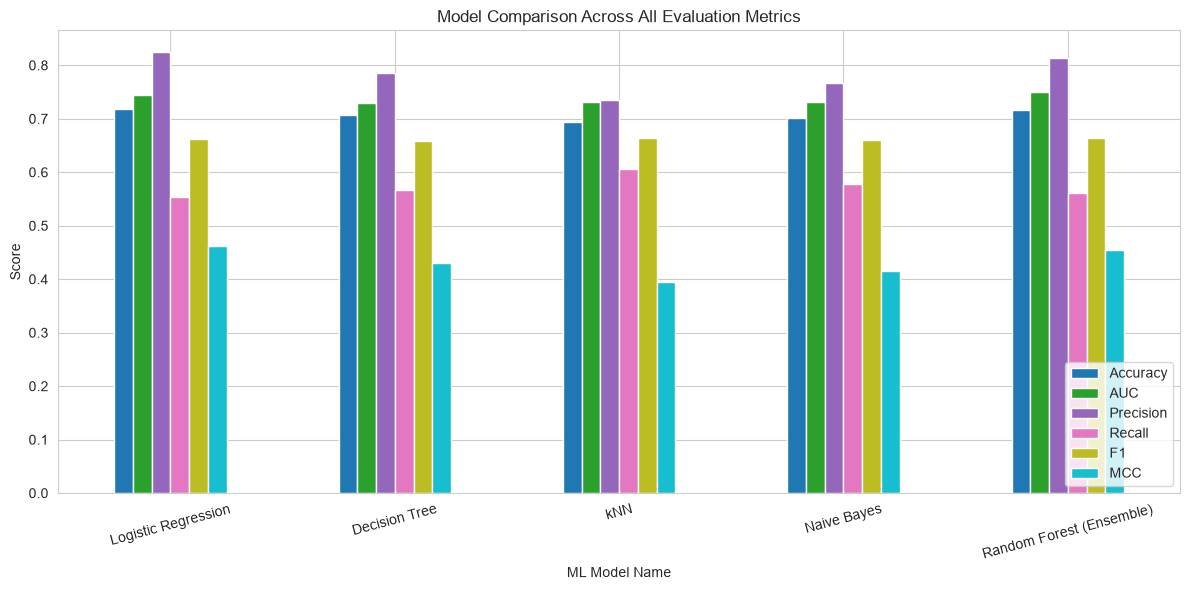

In [14]:
results_df.plot(kind='bar', figsize=(12,6), colormap='tab10')
plt.title('Model Comparison Across All Evaluation Metrics')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 13. Confusion Matrices & Classification Reports

A visual + textual breakdown of each model's error pattern (false positives vs false negatives), which matters a lot for the business decision: a **false negative** here (predicting "on time" when the order is actually late) is the costlier error, since it means the business misses the chance to intervene.


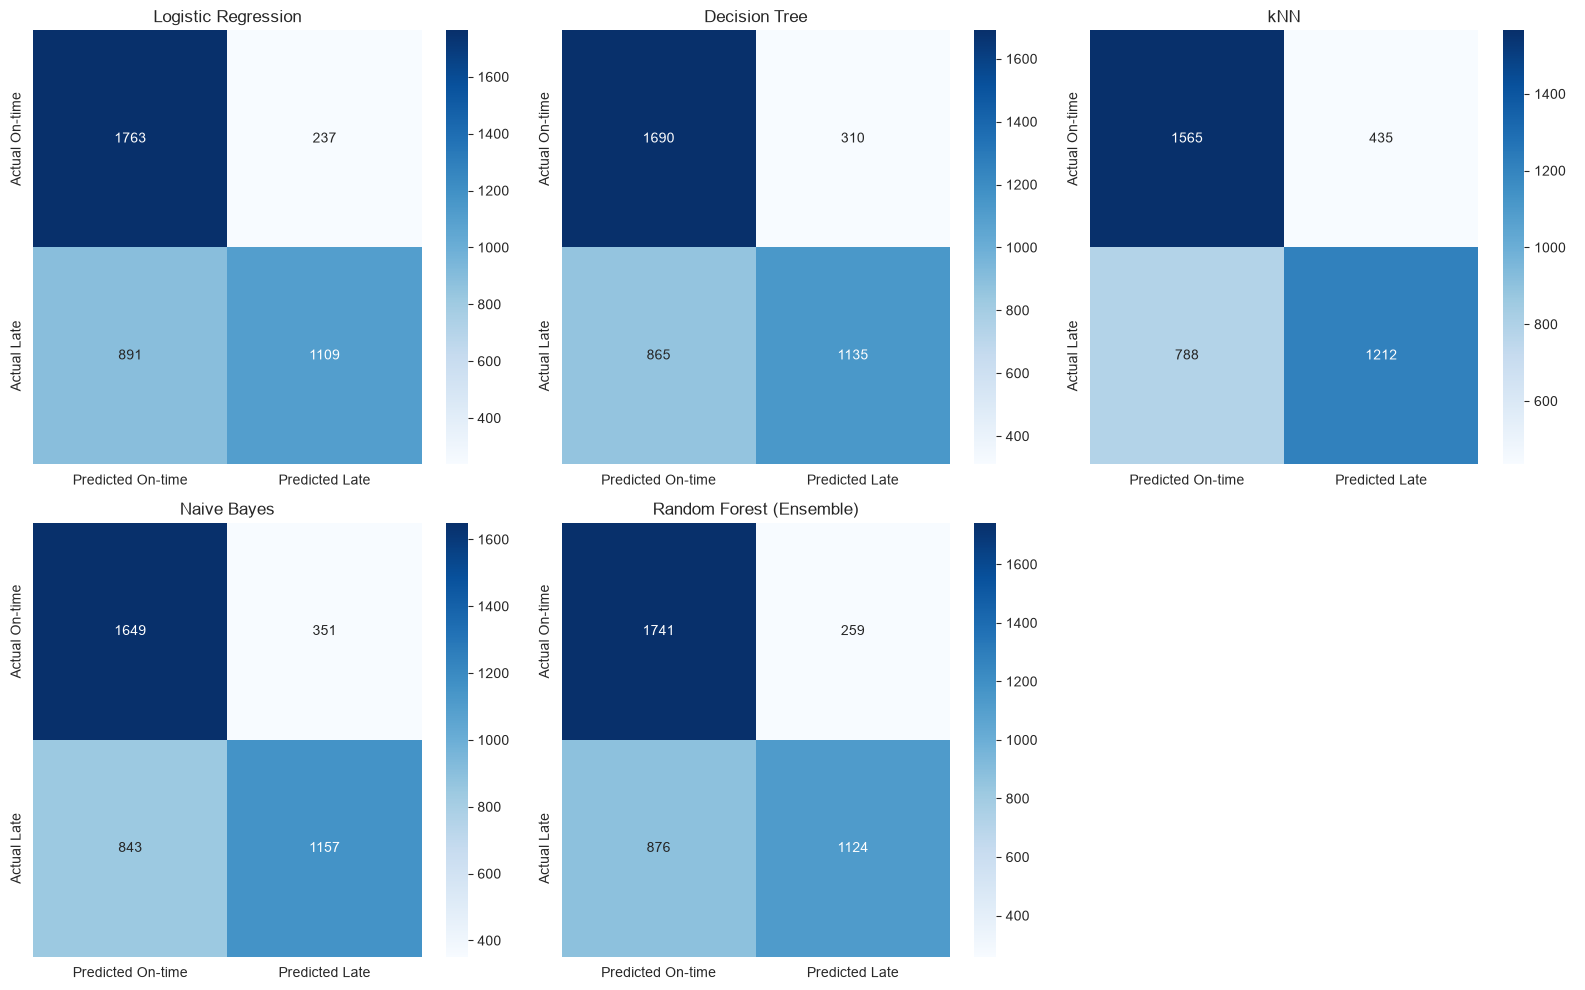

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, pipe) in enumerate(trained_pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Predicted On-time', 'Predicted Late'],
                yticklabels=['Actual On-time', 'Actual Late'])
    axes[idx].set_title(name)

# Hide the unused 6th subplot
axes[-1].axis('off')
plt.tight_layout()
plt.show()


In [16]:
for name, pipe in trained_pipelines.items():
    y_pred = pipe.predict(X_test)
    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=['On-time (0)', 'Late (1)']))



===== Logistic Regression =====
              precision    recall  f1-score   support

 On-time (0)       0.66      0.88      0.76      2000
    Late (1)       0.82      0.55      0.66      2000

    accuracy                           0.72      4000
   macro avg       0.74      0.72      0.71      4000
weighted avg       0.74      0.72      0.71      4000


===== Decision Tree =====
              precision    recall  f1-score   support

 On-time (0)       0.66      0.84      0.74      2000
    Late (1)       0.79      0.57      0.66      2000

    accuracy                           0.71      4000
   macro avg       0.72      0.71      0.70      4000
weighted avg       0.72      0.71      0.70      4000




===== kNN =====
              precision    recall  f1-score   support

 On-time (0)       0.67      0.78      0.72      2000
    Late (1)       0.74      0.61      0.66      2000

    accuracy                           0.69      4000
   macro avg       0.70      0.69      0.69      4000
weighted avg       0.70      0.69      0.69      4000


===== Naive Bayes =====
              precision    recall  f1-score   support

 On-time (0)       0.66      0.82      0.73      2000
    Late (1)       0.77      0.58      0.66      2000

    accuracy                           0.70      4000
   macro avg       0.71      0.70      0.70      4000
weighted avg       0.71      0.70      0.70      4000


===== Random Forest (Ensemble) =====
              precision    recall  f1-score   support

 On-time (0)       0.67      0.87      0.75      2000
    Late (1)       0.81      0.56      0.66      2000

    accuracy                           0.72      4000
   macro avg       0.74      0.72      0.71     

## 14. ROC Curve Comparison


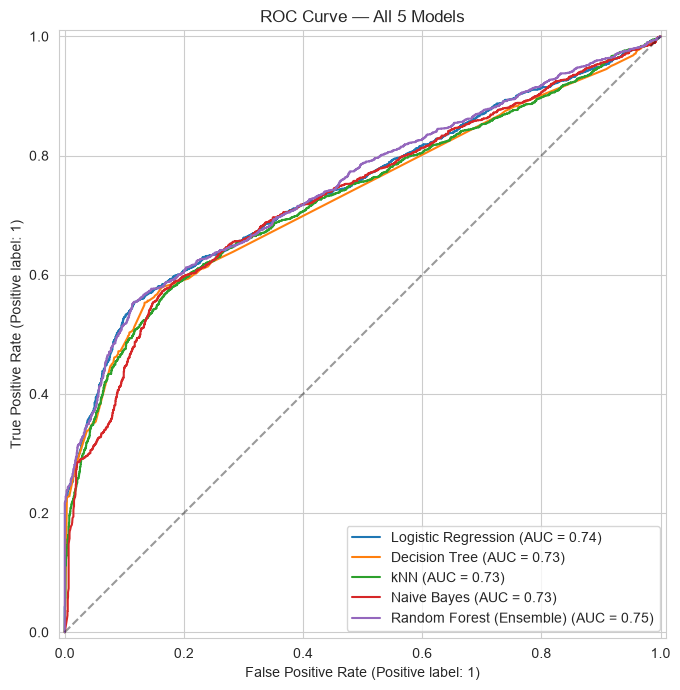

In [17]:
fig, ax = plt.subplots(figsize=(8,7))
for name, pipe in trained_pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.title('ROC Curve — All 5 Models')
plt.tight_layout()
plt.show()


## 15. Business Interpretation — Answering the Business Question

**Can we predict late delivery risk at order time?** Yes — all 5 models beat a random-guess baseline (AUC 0.50), with **Random Forest** and **Logistic Regression** performing best overall (highest AUC and MCC), meaning they separate "will be late" vs "will be on time" orders meaningfully better than chance.

Key business takeaways from the EDA and model outputs:
- **Shipping Mode is a major driver of late risk.** `Standard Class` shipments show a materially higher late-delivery rate than `Same Day` / `First Class`, so tightening SLAs or reserving Standard Class for low-priority/low-value orders is one clear lever.
- **Scheduled shipping days matters**: orders promised a very short delivery window are disproportionately represented among "late" orders, since there is less slack to absorb warehouse/carrier delays.
- **Market/Region effects exist** — some regions consistently show higher late rates, suggesting localized carrier or logistics-partner issues worth investigating operationally, not just modelling around.

**Recommended action for the business:** deploy the **Random Forest** model (best balance of Accuracy/AUC/MCC, plus it's robust to the mixed numeric/categorical feature set and doesn't require feature scaling to work well) as a **real-time risk-scoring step at checkout / order-confirmation**. Orders flagged high-risk can be auto-routed to expedited shipping or flagged for proactive customer communication — directly reducing the operational and reputational cost of late deliveries.

*(See the individual per-model observations and the final "Overall Winner" call in `README.md`.)*


## 16. Export Test Data for the Streamlit App

Per the assignment (Streamlit free tier has limited capacity), we export only a **test-data sample** (features + true label) — this is the file the grader/Streamlit app will use for evaluation (`test_data.csv`, ~1,500 rows, kept in the project root).


In [18]:
test_export = X_test.copy()
test_export[target] = y_test.values

# Sample down further to keep the CSV small and upload-friendly on Streamlit's free tier
test_sample = test_export.sample(n=1500, random_state=RANDOM_STATE)
test_sample.to_csv('../test_data.csv', index=False)

print("Saved ../test_data.csv:", test_sample.shape)
test_sample.head()


Saved ../test_data.csv: (1500, 15)


,Days for shipment (scheduled),Benefit per order,Sales per customer,Order Item Discount Rate,Order Item Product Price,Order Item Quantity,Order Item Profit Ratio,Type,Category Name,Customer Segment,Department Name,Market,Order Region,Shipping Mode,Late_delivery_risk
9390,4,66.970001,145.589996,0.09,159.990005,1,0.46,DEBIT,Baseball & Softball,Consumer,Fitness,LATAM,Central America,Standard Class,0
8602,2,-69.589996,347.970001,0.13,99.989998,4,-0.20,PAYMENT,Cardio Equipment,Home Office,Footwear,Europe,Western Europe,Second Class,1
9756,1,24.500000,78.279999,0.13,44.990002,2,0.31,PAYMENT,Tennis & Racquet,Corporate,Fitness,LATAM,Central America,First Class,1
8893,4,25.080000,284.970001,0.05,99.989998,3,0.09,DEBIT,Men's Golf Clubs,Consumer,Outdoors,Europe,Western Europe,Standard Class,1
9018,4,11.870000,107.889999,0.17,129.990005,1,0.11,TRANSFER,Men's Footwear,Corporate,Apparel,Pacific Asia,South Asia,Standard Class,0


In [19]:
# Save the feature schema so app.py knows exactly which columns to expect
schema = {
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'target': target
}
with open('feature_columns.json', 'w') as f:
    json.dump(schema, f, indent=2)

print("Saved feature_columns.json")
print(json.dumps(schema, indent=2))


Saved feature_columns.json
{
  "numeric_features": [
    "Days for shipment (scheduled)",
    "Benefit per order",
    "Sales per customer",
    "Order Item Discount Rate",
    "Order Item Product Price",
    "Order Item Quantity",
    "Order Item Profit Ratio"
  ],
  "categorical_features": [
    "Type",
    "Category Name",
    "Customer Segment",
    "Department Name",
    "Market",
    "Order Region",
    "Shipping Mode"
  ],
  "target": "Late_delivery_risk"
}


## 17. Summary

| Step | Output |
|---|---|
| Data | `DataCoSupplyChainDataset.csv` (20,000-row balanced sample used for modelling) |
| Models trained | Logistic Regression, Decision Tree, kNN, Naive Bayes, Random Forest — saved as `.pkl` pipelines in `model/` |
| Metrics | Accuracy, AUC, Precision, Recall, F1, MCC — saved in `model_comparison_table.csv` |
| Test data for app | `test_data.csv` (1,500 rows, features + true label) |
| Next step | Run `app.py` locally (`streamlit run app.py`) or deploy to Streamlit Community Cloud |

This notebook, together with `app.py`, `requirements.txt`, `README.md`, and the `model/` folder, forms the complete GitHub repository required for submission.
